In [1]:
from google.colab import drive

drive.mount(
    "/content/drive"
)

Mounted at /content/drive


In [2]:
from pathlib import Path

import torch


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1"
)

REPO_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1-repo"
)

TASK4_REPO_ROOT = (
    REPO_ROOT / "task4"
)

TASK4_WORK_ROOT = (
    PROJECT_ROOT / "task4"
)

DATA_ROOT = (
    PROJECT_ROOT / "datasets"
)

CHECKPOINT_PATHS = {
    "vanilla": (
        TASK4_WORK_ROOT
        / "checkpoints/vanilla_best.pt"
    ),
    "gcsc": (
        TASK4_WORK_ROOT
        / "checkpoints/gcsc_best.pt"
    ),
    "proser": (
        TASK4_WORK_ROOT
        / "checkpoints/proser_best.pt"
    ),
}

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Repository:", REPO_ROOT)
print("Device:", DEVICE)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "Change the Colab runtime to GPU."
    )

for model_name, checkpoint_path in (
    CHECKPOINT_PATHS.items()
):
    print(
        model_name,
        "| checkpoint exists:",
        checkpoint_path.exists(),
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            checkpoint_path
        )

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

Repository: /content/drive/MyDrive/ATML/PA1-repo
Device: cuda
vanilla | checkpoint exists: True
gcsc | checkpoint exists: True
proser | checkpoint exists: True
GPU: Tesla T4


In [3]:
%cd /content/drive/MyDrive/ATML/PA1-repo

import importlib
import inspect
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

from sklearn.metrics import (
    auc,
    roc_auc_score,
    roc_curve,
)

from torch.utils.data import (
    DataLoader,
    Dataset,
)

from torchvision.datasets import (
    CIFAR100,
)

from tqdm.auto import tqdm

from common.seed import set_seed

from task4.data.cifar10 import (
    build_cifar10_loaders,
    build_cifar10_output_datasets,
)

from task4.methods.proser import (
    PROSERModel,
)

from task4.models.resnet_cifar import (
    CIFARResNet18,
)


msp_module = importlib.import_module(
    "task4.scores.msp"
)

mls_module = importlib.import_module(
    "task4.scores.mls"
)

energy_module = importlib.import_module(
    "task4.scores.energy"
)

mahalanobis_module = (
    importlib.import_module(
        "task4.scores.mahalanobis"
    )
)

proser_score_module = (
    importlib.import_module(
        "task4.scores.proser"
    )
)


SEED = 6304

set_seed(SEED)

print("Imports completed.")

/content/drive/MyDrive/ATML/PA1-repo
Imports completed.


In [4]:
split_path = (
    TASK4_REPO_ROOT
    / "splits/"
    "cifar10_train_val_seed6304.json"
)

with split_path.open(
    "r",
    encoding="utf-8",
) as split_file:
    cifar10_split = json.load(
        split_file
    )

with (
    TASK4_REPO_ROOT
    / "results/"
    "vanilla_score_thresholds.json"
).open(
    "r",
    encoding="utf-8",
) as threshold_file:
    vanilla_thresholds = json.load(
        threshold_file
    )

with (
    TASK4_REPO_ROOT
    / "results/"
    "gcsc_mls_threshold.json"
).open(
    "r",
    encoding="utf-8",
) as threshold_file:
    gcsc_thresholds = json.load(
        threshold_file
    )

with (
    TASK4_REPO_ROOT
    / "results/"
    "proser_score_thresholds.json"
).open(
    "r",
    encoding="utf-8",
) as threshold_file:
    proser_thresholds = json.load(
        threshold_file
    )

print(
    "Vanilla scores:",
    list(vanilla_thresholds.keys()),
)

print(
    "GCSC threshold data:",
    gcsc_thresholds,
)

print(
    "PROSER scores:",
    list(proser_thresholds.keys()),
)

Vanilla scores: ['model', 'percentile', 'calibration_split', 'cifar100_used', 'thresholds']
GCSC threshold data: {'model': 'gcsc', 'score': 'mls', 'percentile': 95, 'calibration_split': 'cifar10_validation', 'threshold': -6.411793231964111, 'cifar100_used': False}
PROSER scores: ['mls', 'placeholder']


In [5]:
score_modules = {
    "msp": msp_module,
    "mls": mls_module,
    "energy": energy_module,
    "mahalanobis": (
        mahalanobis_module
    ),
    "proser": (
        proser_score_module
    ),
}

print("Available score functions:")

for module_name, module in (
    score_modules.items()
):
    print()
    print(module_name)

    for object_name in dir(module):
        if object_name.startswith("_"):
            continue

        object_value = getattr(
            module,
            object_name,
        )

        if inspect.isfunction(
            object_value
        ):
            print(
                " -",
                object_name,
                inspect.signature(
                    object_value
                ),
            )

print()
print("Task 4 data files:")

for file_path in sorted(
    (
        TASK4_REPO_ROOT
        / "data"
    ).glob("*.py")
):
    print(file_path.name)

Available score functions:

msp
 - msp_unknownness (logits)

mls
 - mls_unknownness (logits)

energy
 - energy_unknownness (logits)

mahalanobis
 - fit_shared_diagonal_gaussian (features, labels, number_of_classes=10, epsilon=1e-06)
 - mahalanobis_unknownness (features, estimator)

proser
 - collapse_dummy_logits (dummy_logits)
 - proser_mls_score (known_logits)
 - proser_placeholder_score (known_logits, dummy_logits, temperature=1024.0)

Task 4 data files:
__init__.py
cifar10.py
cifar100_open_set.py
make_splits.py


In [6]:
%%writefile task4/data/cifar100_open_set.py
from torch.utils.data import Dataset

from torchvision.datasets import CIFAR100

from task4.data.cifar10 import (
    build_cifar10_evaluation_transform,
)


NEAR_UNKNOWN_CLASSES = (
    "bus",
    "pickup_truck",
    "motorcycle",
    "tractor",
    "wolf",
    "fox",
    "leopard",
    "camel",
)

FAR_UNKNOWN_CLASSES = (
    "bottle",
    "bowl",
    "chair",
    "clock",
    "keyboard",
    "mushroom",
    "sunflower",
    "wardrobe",
)


class CIFAR100UnknownSubset(Dataset):
    def __init__(
        self,
        dataset,
        class_names,
        group_name,
    ):
        self.dataset = dataset
        self.class_names = tuple(
            class_names
        )

        self.group_name = str(
            group_name
        )

        missing_classes = [
            class_name
            for class_name
            in self.class_names
            if class_name
            not in dataset.class_to_idx
        ]

        if missing_classes:
            raise ValueError(
                "Missing CIFAR-100 classes: "
                f"{missing_classes}"
            )

        self.class_indices = {
            dataset.class_to_idx[
                class_name
            ]
            for class_name
            in self.class_names
        }

        self.indices = [
            index
            for index, label
            in enumerate(dataset.targets)
            if label
            in self.class_indices
        ]

        if len(self.indices) != 800:
            raise ValueError(
                f"{self.group_name} must "
                "contain exactly 800 images, "
                f"but found {len(self.indices)}."
            )

    def __len__(self):
        return len(self.indices)

    def __getitem__(
        self,
        item,
    ):
        dataset_index = (
            self.indices[item]
        )

        image, original_label = (
            self.dataset[
                dataset_index
            ]
        )

        return {
            "image": image,
            "original_label": (
                int(original_label)
            ),
            "original_class": (
                self.dataset.classes[
                    original_label
                ]
            ),
            "group": self.group_name,
            "dataset_index": (
                int(dataset_index)
            ),
        }


def build_cifar100_unknown_datasets(
    data_root,
    download=True,
):
    evaluation_transform = (
        build_cifar10_evaluation_transform()
    )

    cifar100_test = CIFAR100(
        root=str(data_root),
        train=False,
        download=download,
        transform=(
            evaluation_transform
        ),
    )

    near_dataset = (
        CIFAR100UnknownSubset(
            dataset=cifar100_test,
            class_names=(
                NEAR_UNKNOWN_CLASSES
            ),
            group_name="near",
        )
    )

    far_dataset = (
        CIFAR100UnknownSubset(
            dataset=cifar100_test,
            class_names=(
                FAR_UNKNOWN_CLASSES
            ),
            group_name="far",
        )
    )

    return {
        "near": near_dataset,
        "far": far_dataset,
    }

Overwriting task4/data/cifar100_open_set.py


In [7]:
!python -m py_compile \
    task4/data/cifar100_open_set.py

from task4.data.cifar100_open_set import (
    FAR_UNKNOWN_CLASSES,
    NEAR_UNKNOWN_CLASSES,
    build_cifar100_unknown_datasets,
)


unknown_datasets = (
    build_cifar100_unknown_datasets(
        data_root=DATA_ROOT,
        download=True,
    )
)

unknown_loaders = {
    group_name: DataLoader(
        dataset,
        batch_size=128,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )
    for group_name, dataset
    in unknown_datasets.items()
}

print(
    "Near classes:",
    NEAR_UNKNOWN_CLASSES,
)

print(
    "Far classes:",
    FAR_UNKNOWN_CLASSES,
)

print(
    "Near samples:",
    len(unknown_datasets["near"]),
)

print(
    "Far samples:",
    len(unknown_datasets["far"]),
)

100%|██████████| 169M/169M [44:48<00:00, 62.9kB/s]


Near classes: ('bus', 'pickup_truck', 'motorcycle', 'tractor', 'wolf', 'fox', 'leopard', 'camel')
Far classes: ('bottle', 'bowl', 'chair', 'clock', 'keyboard', 'mushroom', 'sunflower', 'wardrobe')
Near samples: 800
Far samples: 800


In [8]:
known_datasets = (
    build_cifar10_output_datasets(
        data_root=DATA_ROOT,
        split=cifar10_split,
        download=True,
    )
)

known_loaders = {
    split_name: DataLoader(
        dataset,
        batch_size=128,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )
    for split_name, dataset
    in known_datasets.items()
}

print(
    "Unaugmented training samples:",
    len(known_datasets["train"]),
)

print(
    "Validation samples:",
    len(known_datasets["validation"]),
)

print(
    "Known test samples:",
    len(known_datasets["test"]),
)

Unaugmented training samples: 45000
Validation samples: 5000
Known test samples: 10000


In [9]:
vanilla_checkpoint = torch.load(
    CHECKPOINT_PATHS["vanilla"],
    map_location="cpu",
)

vanilla_model = CIFARResNet18(
    number_of_outputs=10
)

vanilla_model.load_state_dict(
    vanilla_checkpoint[
        "model_state_dict"
    ]
)

vanilla_model = (
    vanilla_model.to(DEVICE)
)

vanilla_model.eval()


gcsc_checkpoint = torch.load(
    CHECKPOINT_PATHS["gcsc"],
    map_location="cpu",
)

gcsc_model = CIFARResNet18(
    number_of_outputs=10
)

gcsc_model.load_state_dict(
    gcsc_checkpoint[
        "model_state_dict"
    ]
)

gcsc_model = gcsc_model.to(
    DEVICE
)

gcsc_model.eval()


proser_checkpoint = torch.load(
    CHECKPOINT_PATHS["proser"],
    map_location="cpu",
)

proser_backbone = CIFARResNet18(
    number_of_outputs=10
)

proser_model = PROSERModel(
    backbone=proser_backbone,
    number_of_dummy_classes=5,
)

proser_model.load_state_dict(
    proser_checkpoint[
        "model_state_dict"
    ]
)

proser_model = proser_model.to(
    DEVICE
)

proser_model.eval()


for model_name, checkpoint in [
    (
        "vanilla",
        vanilla_checkpoint,
    ),
    (
        "gcsc",
        gcsc_checkpoint,
    ),
    (
        "proser",
        proser_checkpoint,
    ),
]:
    print(
        model_name,
        "| selected epoch:",
        checkpoint["epoch"],
        "| validation score:",
        checkpoint["selection_score"],
    )

vanilla | selected epoch: 95 | validation score: 0.9516
gcsc | selected epoch: 99 | validation score: 0.9586
proser | selected epoch: 4 | validation score: 0.9508


In [10]:
def extract_model_outputs(
    model,
    data_loader,
    device,
    description,
    is_proser=False,
):
    model.eval()

    known_logits_list = []
    dummy_logits_list = []
    features_list = []
    labels_list = []
    dataset_indices = []
    original_classes = []

    with torch.inference_mode():
        for batch in tqdm(
            data_loader,
            desc=description,
        ):
            images = batch["image"].to(
                device,
                non_blocking=True,
            )

            if is_proser:
                (
                    known_logits,
                    dummy_logits,
                    features,
                ) = model(
                    images,
                    return_features=True,
                )

                dummy_logits_list.append(
                    dummy_logits.cpu()
                )

            else:
                (
                    known_logits,
                    features,
                ) = model(
                    images,
                    return_features=True,
                )

            known_logits_list.append(
                known_logits.cpu()
            )

            features_list.append(
                features.cpu()
            )

            if "label" in batch:
                labels_list.append(
                    batch["label"].cpu()
                )

            if "dataset_index" in batch:
                batch_indices = (
                    batch["dataset_index"]
                )

                if torch.is_tensor(
                    batch_indices
                ):
                    dataset_indices.extend(
                        batch_indices.tolist()
                    )
                else:
                    dataset_indices.extend(
                        [
                            int(index)
                            for index
                            in batch_indices
                        ]
                    )

            if "original_class" in batch:
                original_classes.extend(
                    list(
                        batch[
                            "original_class"
                        ]
                    )
                )

    outputs = {
        "known_logits": torch.cat(
            known_logits_list,
            dim=0,
        ),
        "features": torch.cat(
            features_list,
            dim=0,
        ),
        "dataset_indices": (
            dataset_indices
        ),
        "original_classes": (
            original_classes
        ),
    }

    if dummy_logits_list:
        outputs["dummy_logits"] = (
            torch.cat(
                dummy_logits_list,
                dim=0,
            )
        )

    if labels_list:
        outputs["labels"] = torch.cat(
            labels_list,
            dim=0,
        )

    return outputs

In [11]:
vanilla_outputs = {}

for split_name in [
    "train",
    "validation",
    "test",
]:
    vanilla_outputs[split_name] = (
        extract_model_outputs(
            model=vanilla_model,
            data_loader=(
                known_loaders[
                    split_name
                ]
            ),
            device=DEVICE,
            description=(
                "Vanilla "
                f"{split_name}"
            ),
            is_proser=False,
        )
    )

for group_name in [
    "near",
    "far",
]:
    vanilla_outputs[group_name] = (
        extract_model_outputs(
            model=vanilla_model,
            data_loader=(
                unknown_loaders[
                    group_name
                ]
            ),
            device=DEVICE,
            description=(
                "Vanilla "
                f"{group_name}"
            ),
            is_proser=False,
        )
    )

print(
    "Vanilla training outputs:",
    vanilla_outputs[
        "train"
    ]["known_logits"].shape,
    vanilla_outputs[
        "train"
    ]["features"].shape,
)

print(
    "Vanilla near outputs:",
    vanilla_outputs[
        "near"
    ]["known_logits"].shape,
)

print(
    "Vanilla far outputs:",
    vanilla_outputs[
        "far"
    ]["known_logits"].shape,
)

Vanilla train:   0%|          | 0/352 [00:00<?, ?it/s]

Vanilla validation:   0%|          | 0/40 [00:00<?, ?it/s]

Vanilla test:   0%|          | 0/79 [00:00<?, ?it/s]

Vanilla near:   0%|          | 0/7 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e9ae52d60c0>
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most recent call last):
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e9ae52d60c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1655, in _shutdown_workers
    self._pin_memory_thread.join()
  File "/usr/lib/python3.13/threading.py", line 1088, in join
    raise RuntimeError("cannot join current thread")
RuntimeError: cannot join current thread
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/proc

Vanilla far:   0%|          | 0/7 [00:00<?, ?it/s]

Vanilla training outputs: torch.Size([45000, 10]) torch.Size([45000, 512])
Vanilla near outputs: torch.Size([800, 10])
Vanilla far outputs: torch.Size([800, 10])


In [12]:
gcsc_outputs = {}
proser_outputs = {}

for split_name in [
    "validation",
    "test",
]:
    gcsc_outputs[split_name] = (
        extract_model_outputs(
            model=gcsc_model,
            data_loader=(
                known_loaders[
                    split_name
                ]
            ),
            device=DEVICE,
            description=(
                f"GCSC {split_name}"
            ),
            is_proser=False,
        )
    )

    proser_outputs[split_name] = (
        extract_model_outputs(
            model=proser_model,
            data_loader=(
                known_loaders[
                    split_name
                ]
            ),
            device=DEVICE,
            description=(
                f"PROSER {split_name}"
            ),
            is_proser=True,
        )
    )

for group_name in [
    "near",
    "far",
]:
    gcsc_outputs[group_name] = (
        extract_model_outputs(
            model=gcsc_model,
            data_loader=(
                unknown_loaders[
                    group_name
                ]
            ),
            device=DEVICE,
            description=(
                f"GCSC {group_name}"
            ),
            is_proser=False,
        )
    )

    proser_outputs[group_name] = (
        extract_model_outputs(
            model=proser_model,
            data_loader=(
                unknown_loaders[
                    group_name
                ]
            ),
            device=DEVICE,
            description=(
                f"PROSER {group_name}"
            ),
            is_proser=True,
        )
    )

print(
    "GCSC known test outputs:",
    gcsc_outputs[
        "test"
    ]["known_logits"].shape,
)

print(
    "PROSER known test outputs:",
    proser_outputs[
        "test"
    ]["known_logits"].shape,
)

print(
    "PROSER dummy outputs:",
    proser_outputs[
        "test"
    ]["dummy_logits"].shape,
)

GCSC validation:   0%|          | 0/40 [00:00<?, ?it/s]

PROSER validation:   0%|          | 0/40 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e9ae52d60c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e9ae52d60c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

GCSC test:   0%|          | 0/79 [00:00<?, ?it/s]

PROSER test:   0%|          | 0/79 [00:00<?, ?it/s]

...

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e9ae52d60c0>
<function _MultiProcessingDataLoaderIter.__del__ at 0x7e9ae52d60c0>Traceback (most recent call last):

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        if w.is_alive():
if w.is_alive():  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive

    assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3.13/multiprocessing/process.py", line 16

PROSER near:   0%|          | 0/7 [00:00<?, ?it/s]

GCSC far:   0%|          | 0/7 [00:00<?, ?it/s]

PROSER far:   0%|          | 0/7 [00:00<?, ?it/s]

GCSC known test outputs: torch.Size([10000, 10])
PROSER known test outputs: torch.Size([10000, 10])
PROSER dummy outputs: torch.Size([10000, 5])


In [14]:
def to_numpy(
    values,
):
    if torch.is_tensor(values):
        return (
            values
            .detach()
            .cpu()
            .numpy()
        )

    return np.asarray(values)


mahalanobis_estimator = (
    mahalanobis_module
    .fit_shared_diagonal_gaussian(
        features=(
            vanilla_outputs[
                "train"
            ]["features"]
        ),
        labels=(
            vanilla_outputs[
                "train"
            ]["labels"]
        ),
        number_of_classes=10,
        epsilon=1e-6,
    )
)


def calculate_vanilla_scores(
    outputs,
):
    logits = outputs[
        "known_logits"
    ]

    features = outputs["features"]

    return {
        "msp": to_numpy(
            msp_module
            .msp_unknownness(
                logits
            )
        ),
        "mls": to_numpy(
            mls_module
            .mls_unknownness(
                logits
            )
        ),
        "energy": to_numpy(
            energy_module
            .energy_unknownness(
                logits
            )
        ),
        "mahalanobis": to_numpy(
            mahalanobis_module
            .mahalanobis_unknownness(
                features,
                mahalanobis_estimator,
            )
        ),
    }


vanilla_scores = {
    split_name: (
        calculate_vanilla_scores(
            split_outputs
        )
    )
    for split_name, split_outputs
    in vanilla_outputs.items()
}


gcsc_scores = {
    split_name: to_numpy(
        mls_module
        .mls_unknownness(
            split_outputs[
                "known_logits"
            ]
        )
    )
    for split_name, split_outputs
    in gcsc_outputs.items()
}


proser_scores = {}

for split_name, split_outputs in (
    proser_outputs.items()
):
    proser_scores[split_name] = {
        "mls": to_numpy(
            proser_score_module
            .proser_mls_score(
                split_outputs[
                    "known_logits"
                ]
            )
        ),
        "placeholder": to_numpy(
            proser_score_module
            .proser_placeholder_score(
                split_outputs[
                    "known_logits"
                ],
                split_outputs[
                    "dummy_logits"
                ],
                temperature=1024.0,
            )
        ),
    }


for score_name, score_values in (
    vanilla_scores["test"].items()
):
    print(
        "Vanilla",
        score_name,
        "| finite:",
        np.isfinite(
            score_values
        ).all(),
        "| shape:",
        score_values.shape,
    )

Vanilla msp | finite: True | shape: (10000,)
Vanilla mls | finite: True | shape: (10000,)
Vanilla energy | finite: True | shape: (10000,)
Vanilla mahalanobis | finite: True | shape: (10000,)


In [15]:
def read_threshold(
    threshold_data,
    score_name,
):
    if (
        "thresholds"
        in threshold_data
    ):
        threshold_value = (
            threshold_data[
                "thresholds"
            ][score_name]
        )

    elif score_name in threshold_data:
        threshold_value = (
            threshold_data[
                score_name
            ]
        )

    elif (
        threshold_data.get(
            "score"
        )
        == score_name
    ):
        threshold_value = (
            threshold_data[
                "threshold"
            ]
        )

    else:
        raise KeyError(
            f"Threshold not found for "
            f"{score_name}."
        )

    if isinstance(
        threshold_value,
        dict,
    ):
        threshold_value = (
            threshold_value[
                "threshold"
            ]
        )

    return float(
        threshold_value
    )


def calculate_osr_metrics(
    known_scores,
    near_scores,
    far_scores,
    threshold,
):
    all_unknown_scores = (
        np.concatenate(
            [
                near_scores,
                far_scores,
            ]
        )
    )

    def binary_auroc(
        unknown_scores,
    ):
        labels = np.concatenate(
            [
                np.zeros(
                    len(known_scores)
                ),
                np.ones(
                    len(unknown_scores)
                ),
            ]
        )

        scores = np.concatenate(
            [
                known_scores,
                unknown_scores,
            ]
        )

        return roc_auc_score(
            labels,
            scores,
        )

    known_acceptance = np.mean(
        known_scores <= threshold
    )

    near_rejection = np.mean(
        near_scores > threshold
    )

    far_rejection = np.mean(
        far_scores > threshold
    )

    all_rejection = np.mean(
        all_unknown_scores
        > threshold
    )

    return {
        "near_auroc": binary_auroc(
            near_scores
        ),
        "far_auroc": binary_auroc(
            far_scores
        ),
        "all_unknown_auroc": (
            binary_auroc(
                all_unknown_scores
            )
        ),
        "threshold": float(
            threshold
        ),
        "known_test_acceptance_rate": (
            known_acceptance
        ),
        "near_rejection_rate": (
            near_rejection
        ),
        "far_rejection_rate": (
            far_rejection
        ),
        "all_unknown_rejection_rate": (
            all_rejection
        ),
        "near_fpr_at_95_tpr": (
            1.0 - near_rejection
        ),
        "far_fpr_at_95_tpr": (
            1.0 - far_rejection
        ),
    }


print(
    "Vanilla MLS threshold:",
    read_threshold(
        vanilla_thresholds,
        "mls",
    ),
)

print(
    "GCSC MLS threshold:",
    read_threshold(
        gcsc_thresholds,
        "mls",
    ),
)

print(
    "PROSER placeholder threshold:",
    read_threshold(
        proser_thresholds,
        "placeholder",
    ),
)

Vanilla MLS threshold: -5.903560161590576
GCSC MLS threshold: -6.411793231964111
PROSER placeholder threshold: 5.8979168534279115e-05


In [16]:
vanilla_comparison_rows = []

for score_name in [
    "msp",
    "mls",
    "energy",
    "mahalanobis",
]:
    threshold = read_threshold(
        vanilla_thresholds,
        score_name,
    )

    metrics = calculate_osr_metrics(
        known_scores=(
            vanilla_scores[
                "test"
            ][score_name]
        ),
        near_scores=(
            vanilla_scores[
                "near"
            ][score_name]
        ),
        far_scores=(
            vanilla_scores[
                "far"
            ][score_name]
        ),
        threshold=threshold,
    )

    vanilla_comparison_rows.append(
        {
            "model": "vanilla",
            "score": score_name,
            **metrics,
        }
    )

vanilla_comparison = pd.DataFrame(
    vanilla_comparison_rows
)

vanilla_comparison_path = (
    TASK4_REPO_ROOT
    / "results/"
    "vanilla_posthoc_osr_comparison.csv"
)

vanilla_comparison.to_csv(
    vanilla_comparison_path,
    index=False,
)

print(
    vanilla_comparison.to_string(
        index=False
    )
)

print()
print(
    "Saved to:",
    vanilla_comparison_path,
)

  model       score  near_auroc  far_auroc  all_unknown_auroc   threshold  known_test_acceptance_rate  near_rejection_rate  far_rejection_rate  all_unknown_rejection_rate  near_fpr_at_95_tpr  far_fpr_at_95_tpr
vanilla         msp    0.803671   0.893990           0.848831    0.160564                      0.9466              0.28250              0.4375                    0.360000             0.71750             0.5625
vanilla         mls    0.785555   0.891070           0.838313   -5.903560                      0.9474              0.31875              0.5400                    0.429375             0.68125             0.4600
vanilla      energy    0.785601   0.891860           0.838731   -6.083649                      0.9482              0.31500              0.5450                    0.430000             0.68500             0.4550
vanilla mahalanobis    0.797372   0.910536           0.853954 3029.122777                      0.9474              0.29250              0.4600                  

In [17]:
def closed_set_accuracy(
    outputs,
):
    predictions = (
        outputs[
            "known_logits"
        ].argmax(
            dim=1
        )
    )

    labels = outputs["labels"]

    return float(
        predictions.eq(
            labels
        )
        .float()
        .mean()
        .item()
    )


trained_method_definitions = [
    {
        "model": "vanilla",
        "score": "mls",
        "csa": closed_set_accuracy(
            vanilla_outputs["test"]
        ),
        "known": (
            vanilla_scores["test"][
                "mls"
            ]
        ),
        "near": (
            vanilla_scores["near"][
                "mls"
            ]
        ),
        "far": (
            vanilla_scores["far"][
                "mls"
            ]
        ),
        "threshold": read_threshold(
            vanilla_thresholds,
            "mls",
        ),
    },
    {
        "model": "gcsc",
        "score": "mls",
        "csa": closed_set_accuracy(
            gcsc_outputs["test"]
        ),
        "known": gcsc_scores["test"],
        "near": gcsc_scores["near"],
        "far": gcsc_scores["far"],
        "threshold": read_threshold(
            gcsc_thresholds,
            "mls",
        ),
    },
    {
        "model": "proser",
        "score": "mls",
        "csa": closed_set_accuracy(
            proser_outputs["test"]
        ),
        "known": (
            proser_scores["test"][
                "mls"
            ]
        ),
        "near": (
            proser_scores["near"][
                "mls"
            ]
        ),
        "far": (
            proser_scores["far"][
                "mls"
            ]
        ),
        "threshold": read_threshold(
            proser_thresholds,
            "mls",
        ),
    },
    {
        "model": "proser",
        "score": "placeholder",
        "csa": closed_set_accuracy(
            proser_outputs["test"]
        ),
        "known": (
            proser_scores["test"][
                "placeholder"
            ]
        ),
        "near": (
            proser_scores["near"][
                "placeholder"
            ]
        ),
        "far": (
            proser_scores["far"][
                "placeholder"
            ]
        ),
        "threshold": read_threshold(
            proser_thresholds,
            "placeholder",
        ),
    },
]

trained_comparison_rows = []

for definition in (
    trained_method_definitions
):
    metrics = calculate_osr_metrics(
        known_scores=(
            definition["known"]
        ),
        near_scores=(
            definition["near"]
        ),
        far_scores=(
            definition["far"]
        ),
        threshold=(
            definition["threshold"]
        ),
    )

    trained_comparison_rows.append(
        {
            "model": (
                definition["model"]
            ),
            "score": (
                definition["score"]
            ),
            "closed_set_accuracy": (
                definition["csa"]
            ),
            **metrics,
        }
    )

trained_model_comparison = (
    pd.DataFrame(
        trained_comparison_rows
    )
)

trained_comparison_path = (
    TASK4_REPO_ROOT
    / "results/"
    "trained_model_osr_comparison.csv"
)

trained_model_comparison.to_csv(
    trained_comparison_path,
    index=False,
)

print(
    trained_model_comparison.to_string(
        index=False
    )
)

print()
print(
    "Saved to:",
    trained_comparison_path,
)

  model       score  closed_set_accuracy  near_auroc  far_auroc  all_unknown_auroc  threshold  known_test_acceptance_rate  near_rejection_rate  far_rejection_rate  all_unknown_rejection_rate  near_fpr_at_95_tpr  far_fpr_at_95_tpr
vanilla         mls               0.9494    0.785555   0.891070           0.838313  -5.903560                      0.9474              0.31875             0.54000                    0.429375             0.68125            0.46000
   gcsc         mls               0.9509    0.810552   0.900242           0.855397  -6.411793                      0.9472              0.36125             0.59875                    0.480000             0.63875            0.40125
 proser         mls               0.9465    0.787914   0.875146           0.831530  -5.327534                      0.9440              0.32375             0.49750                    0.410625             0.67625            0.50250
 proser placeholder               0.9465    0.782531   0.875711           0.8291

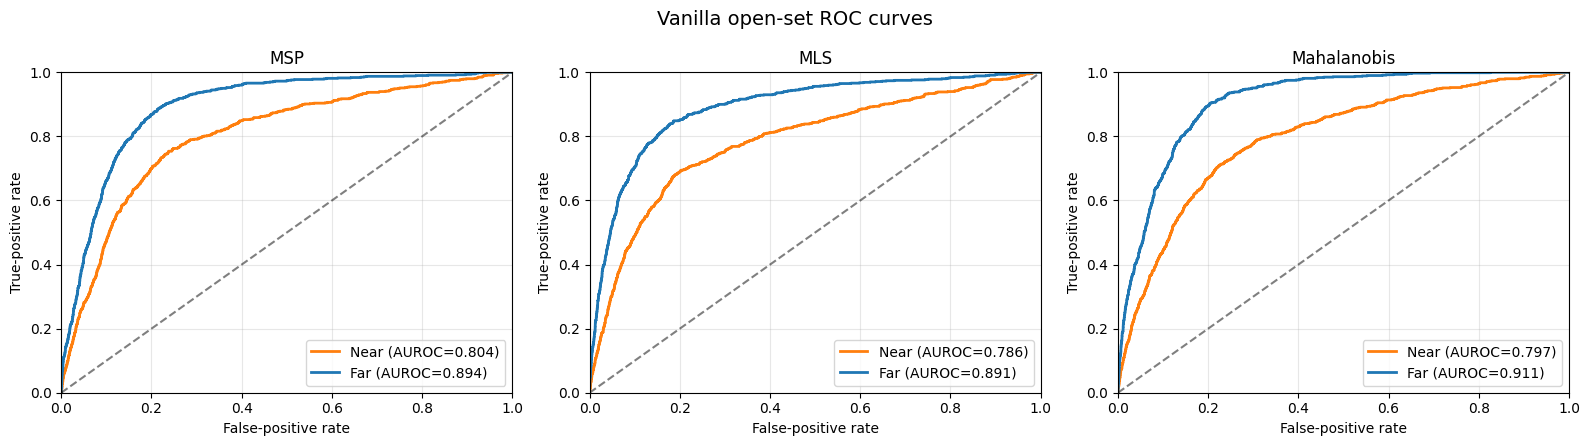

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task4/figures/vanilla_score_roc_curves.png


In [18]:
roc_score_names = [
    "msp",
    "mls",
    "mahalanobis",
]

score_titles = {
    "msp": "MSP",
    "mls": "MLS",
    "mahalanobis": "Mahalanobis",
}

figure, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5),
)

for axis, score_name in zip(
    axes,
    roc_score_names,
):
    known_score_values = (
        vanilla_scores[
            "test"
        ][score_name]
    )

    for group_name, color in [
        ("near", "tab:orange"),
        ("far", "tab:blue"),
    ]:
        unknown_score_values = (
            vanilla_scores[
                group_name
            ][score_name]
        )

        binary_labels = np.concatenate(
            [
                np.zeros(
                    len(
                        known_score_values
                    )
                ),
                np.ones(
                    len(
                        unknown_score_values
                    )
                ),
            ]
        )

        combined_scores = (
            np.concatenate(
                [
                    known_score_values,
                    unknown_score_values,
                ]
            )
        )

        false_positive_rate, (
            true_positive_rate
        ), _ = roc_curve(
            binary_labels,
            combined_scores,
        )

        auroc_value = roc_auc_score(
            binary_labels,
            combined_scores,
        )

        axis.plot(
            false_positive_rate,
            true_positive_rate,
            color=color,
            linewidth=2,
            label=(
                f"{group_name.title()} "
                f"(AUROC={auroc_value:.3f})"
            ),
        )

    axis.plot(
        [0, 1],
        [0, 1],
        color="black",
        linestyle="--",
        alpha=0.5,
    )

    axis.set_title(
        score_titles[score_name]
    )

    axis.set_xlabel(
        "False-positive rate"
    )

    axis.set_ylabel(
        "True-positive rate"
    )

    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.grid(alpha=0.3)
    axis.legend()

figure.suptitle(
    "Vanilla open-set ROC curves",
    fontsize=14,
)

figure.tight_layout()

roc_figure_path = (
    TASK4_REPO_ROOT
    / "figures/"
    "vanilla_score_roc_curves.png"
)

roc_figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    roc_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    roc_figure_path,
)

In [19]:
CIFAR10_CLASS_NAMES = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)

vanilla_mls_threshold = (
    read_threshold(
        vanilla_thresholds,
        "mls",
    )
)

failure_rows = []

for group_name in [
    "near",
    "far",
]:
    group_outputs = (
        vanilla_outputs[
            group_name
        ]
    )

    group_scores = (
        vanilla_scores[
            group_name
        ]["mls"]
    )

    group_predictions = (
        group_outputs[
            "known_logits"
        ]
        .argmax(dim=1)
        .numpy()
    )

    for item_index in range(
        len(group_scores)
    ):
        score = float(
            group_scores[
                item_index
            ]
        )

        if score <= (
            vanilla_mls_threshold
        ):
            prediction = int(
                group_predictions[
                    item_index
                ]
            )

            failure_rows.append(
                {
                    "group": group_name,
                    "dataset_index": int(
                        group_outputs[
                            "dataset_indices"
                        ][item_index]
                    ),
                    "unknown_class": (
                        group_outputs[
                            "original_classes"
                        ][item_index]
                    ),
                    "predicted_known_index": (
                        prediction
                    ),
                    "predicted_known_class": (
                        CIFAR10_CLASS_NAMES[
                            prediction
                        ]
                    ),
                    "mls_score": score,
                    "threshold": (
                        vanilla_mls_threshold
                    ),
                }
            )

accepted_unknowns = pd.DataFrame(
    failure_rows
)

accepted_unknowns = (
    accepted_unknowns.sort_values(
        [
            "group",
            "mls_score",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

failure_summary = (
    accepted_unknowns
    .groupby(
        [
            "group",
            "unknown_class",
            "predicted_known_class",
        ]
    )
    .size()
    .reset_index(
        name="number_accepted"
    )
    .sort_values(
        [
            "group",
            "number_accepted",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

selected_failure_rows = []

for group_name in [
    "near",
    "far",
]:
    group_failures = (
        accepted_unknowns[
            accepted_unknowns[
                "group"
            ]
            == group_name
        ]
    )

    selected_classes = set()

    for _, failure_row in (
        group_failures.iterrows()
    ):
        unknown_class = (
            failure_row[
                "unknown_class"
            ]
        )

        if (
            unknown_class
            not in selected_classes
        ):
            selected_failure_rows.append(
                failure_row
            )

            selected_classes.add(
                unknown_class
            )

        if len(selected_classes) == 3:
            break

selected_failures = pd.DataFrame(
    selected_failure_rows
).reset_index(drop=True)

accepted_unknowns_path = (
    TASK4_REPO_ROOT
    / "results/"
    "vanilla_mls_accepted_unknowns.csv"
)

failure_summary_path = (
    TASK4_REPO_ROOT
    / "results/"
    "vanilla_mls_failure_summary.csv"
)

selected_failures_path = (
    TASK4_REPO_ROOT
    / "results/"
    "vanilla_mls_selected_failures.csv"
)

accepted_unknowns.to_csv(
    accepted_unknowns_path,
    index=False,
)

failure_summary.to_csv(
    failure_summary_path,
    index=False,
)

selected_failures.to_csv(
    selected_failures_path,
    index=False,
)

print("Failure counts by class:")
print(
    failure_summary.to_string(
        index=False
    )
)

print()
print("Selected examples:")
print(
    selected_failures.to_string(
        index=False
    )
)

Failure counts by class:
group unknown_class predicted_known_class  number_accepted
  far      wardrobe                 truck               40
  far      wardrobe                   cat               32
  far         chair              airplane               29
  far     sunflower                  bird               26
  far      mushroom                  bird               25
  far      keyboard              airplane               14
  far        bottle                  ship               13
  far          bowl                   cat               13
  far      mushroom                  frog               12
  far        bottle                   cat               11
  far         clock                   cat               11
  far         clock            automobile               10
  far      keyboard                   cat               10
  far         clock                 truck                9
  far      keyboard                 truck                9
  far        bottle            

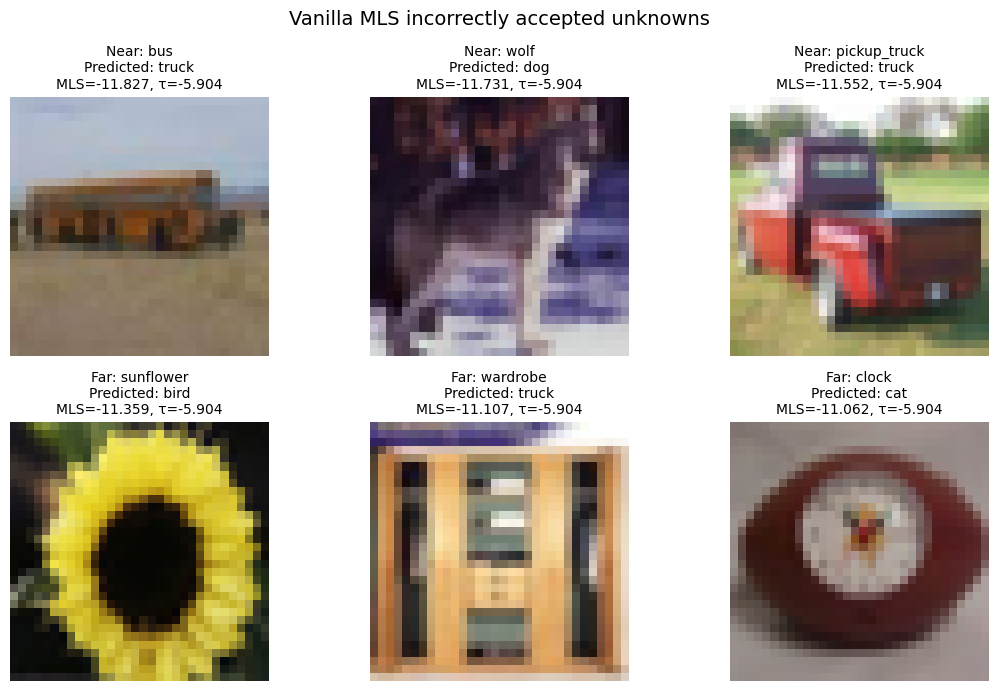

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task4/figures/vanilla_mls_failure_examples.png


In [20]:
figure, axes = plt.subplots(
    2,
    3,
    figsize=(11, 7),
)

for axis, (_, failure) in zip(
    axes.flatten(),
    selected_failures.iterrows(),
):
    group_name = failure["group"]

    dataset_index = int(
        failure["dataset_index"]
    )

    image = (
        unknown_datasets[
            group_name
        ]
        .dataset
        .data[
            dataset_index
        ]
    )

    axis.imshow(image)

    axis.set_title(
        (
            f"{group_name.title()}: "
            f"{failure['unknown_class']}\n"
            f"Predicted: "
            f"{failure['predicted_known_class']}\n"
            f"MLS={failure['mls_score']:.3f}, "
            f"τ={failure['threshold']:.3f}"
        ),
        fontsize=10,
    )

    axis.axis("off")

figure.suptitle(
    "Vanilla MLS incorrectly accepted unknowns",
    fontsize=14,
)

figure.tight_layout()

failure_figure_path = (
    TASK4_REPO_ROOT
    / "figures/"
    "vanilla_mls_failure_examples.png"
)

figure.savefig(
    failure_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    failure_figure_path,
)

In [21]:
prediction_rows = []
per_class_rows = []

evaluation_definitions = [
    (
        "vanilla",
        "mls",
        vanilla_outputs,
        vanilla_scores,
        read_threshold(
            vanilla_thresholds,
            "mls",
        ),
    ),
    (
        "gcsc",
        "mls",
        gcsc_outputs,
        {
            group_name: {
                "mls": score_values
            }
            for group_name, score_values
            in gcsc_scores.items()
        },
        read_threshold(
            gcsc_thresholds,
            "mls",
        ),
    ),
    (
        "proser",
        "mls",
        proser_outputs,
        proser_scores,
        read_threshold(
            proser_thresholds,
            "mls",
        ),
    ),
    (
        "proser",
        "placeholder",
        proser_outputs,
        proser_scores,
        read_threshold(
            proser_thresholds,
            "placeholder",
        ),
    ),
]

for (
    model_name,
    score_name,
    output_dictionary,
    score_dictionary,
    threshold,
) in evaluation_definitions:
    for group_name in [
        "near",
        "far",
    ]:
        group_outputs = (
            output_dictionary[
                group_name
            ]
        )

        group_scores = (
            score_dictionary[
                group_name
            ][score_name]
        )

        predictions = (
            group_outputs[
                "known_logits"
            ]
            .argmax(dim=1)
            .numpy()
        )

        group_rows = []

        for item_index in range(
            len(group_scores)
        ):
            prediction = int(
                predictions[
                    item_index
                ]
            )

            score = float(
                group_scores[
                    item_index
                ]
            )

            prediction_row = {
                "model": model_name,
                "score": score_name,
                "group": group_name,
                "dataset_index": int(
                    group_outputs[
                        "dataset_indices"
                    ][item_index]
                ),
                "unknown_class": (
                    group_outputs[
                        "original_classes"
                    ][item_index]
                ),
                "predicted_known_class": (
                    CIFAR10_CLASS_NAMES[
                        prediction
                    ]
                ),
                "unknownness": score,
                "threshold": float(
                    threshold
                ),
                "rejected": bool(
                    score > threshold
                ),
            }

            prediction_rows.append(
                prediction_row
            )

            group_rows.append(
                prediction_row
            )

        group_table = pd.DataFrame(
            group_rows
        )

        for unknown_class in sorted(
            group_table[
                "unknown_class"
            ].unique()
        ):
            class_table = (
                group_table[
                    group_table[
                        "unknown_class"
                    ]
                    == unknown_class
                ]
            )

            most_common_prediction = (
                class_table[
                    "predicted_known_class"
                ]
                .value_counts()
                .idxmax()
            )

            per_class_rows.append(
                {
                    "model": model_name,
                    "score": score_name,
                    "group": group_name,
                    "unknown_class": (
                        unknown_class
                    ),
                    "number_of_samples": (
                        len(class_table)
                    ),
                    "rejection_rate": float(
                        class_table[
                            "rejected"
                        ].mean()
                    ),
                    "acceptance_rate": float(
                        1.0
                        - class_table[
                            "rejected"
                        ].mean()
                    ),
                    "most_common_known_prediction": (
                        most_common_prediction
                    ),
                    "most_common_prediction_count": int(
                        class_table[
                            "predicted_known_class"
                        ]
                        .value_counts()
                        .max()
                    ),
                }
            )

open_set_predictions = pd.DataFrame(
    prediction_rows
)

per_class_results = pd.DataFrame(
    per_class_rows
)

prediction_path = (
    TASK4_REPO_ROOT
    / "results/"
    "open_set_unknown_predictions.csv"
)

per_class_path = (
    TASK4_REPO_ROOT
    / "results/"
    "open_set_per_class_results.csv"
)

open_set_predictions.to_csv(
    prediction_path,
    index=False,
)

per_class_results.to_csv(
    per_class_path,
    index=False,
)

print(
    per_class_results.to_string(
        index=False
    )
)

print()
print(
    "Predictions saved to:",
    prediction_path,
)

print(
    "Per-class results saved to:",
    per_class_path,
)

  model       score group unknown_class  number_of_samples  rejection_rate  acceptance_rate most_common_known_prediction  most_common_prediction_count
vanilla         mls  near           bus                100            0.18             0.82                        truck                            76
vanilla         mls  near         camel                100            0.43             0.57                        horse                            28
vanilla         mls  near           fox                100            0.37             0.63                          cat                            34
vanilla         mls  near       leopard                100            0.25             0.75                          cat                            40
vanilla         mls  near    motorcycle                100            0.64             0.36                        truck                            29
vanilla         mls  near  pickup_truck                100            0.11             0.89   

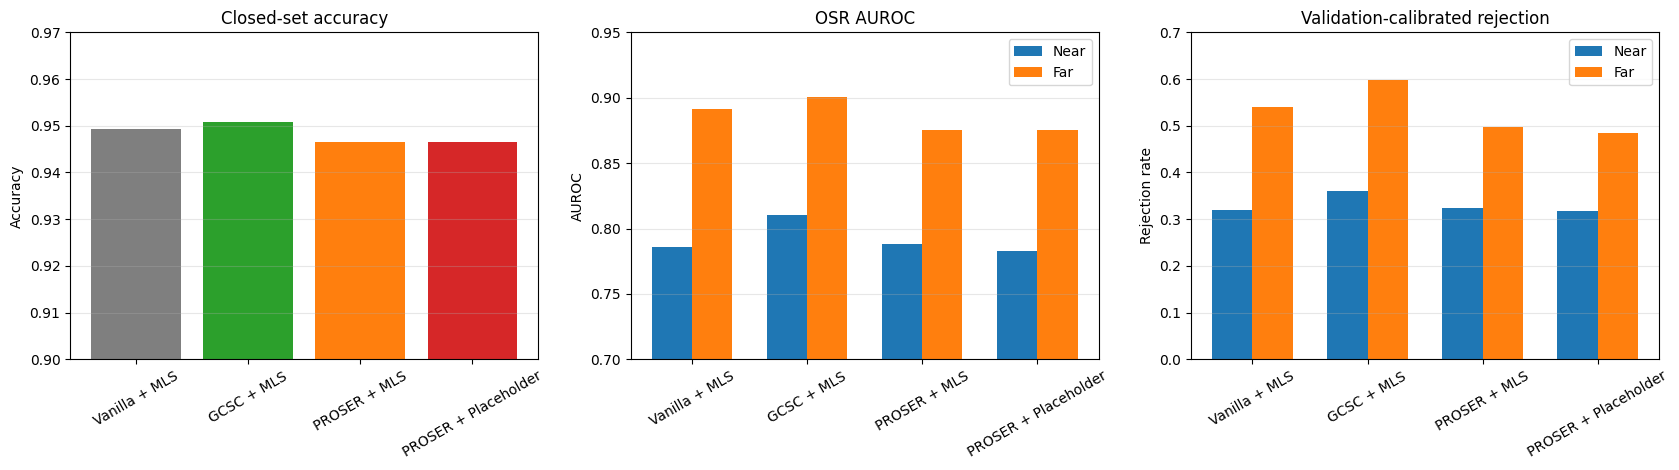

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task4/figures/trained_model_osr_comparison.png


In [22]:
plot_table = (
    trained_model_comparison.copy()
)

plot_table["display_name"] = [
    "Vanilla + MLS",
    "GCSC + MLS",
    "PROSER + MLS",
    "PROSER + Placeholder",
]

figure, axes = plt.subplots(
    1,
    3,
    figsize=(17, 4.8),
)

axes[0].bar(
    plot_table["display_name"],
    plot_table[
        "closed_set_accuracy"
    ],
    color=[
        "tab:gray",
        "tab:green",
        "tab:orange",
        "tab:red",
    ],
)

axes[0].set_title(
    "Closed-set accuracy"
)

axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.90, 0.97)
axes[0].tick_params(
    axis="x",
    rotation=30,
)

axes[0].grid(
    axis="y",
    alpha=0.3,
)

bar_width = 0.35

positions = np.arange(
    len(plot_table)
)

axes[1].bar(
    positions - bar_width / 2,
    plot_table["near_auroc"],
    width=bar_width,
    label="Near",
)

axes[1].bar(
    positions + bar_width / 2,
    plot_table["far_auroc"],
    width=bar_width,
    label="Far",
)

axes[1].set_xticks(
    positions,
    plot_table["display_name"],
    rotation=30,
)

axes[1].set_title("OSR AUROC")
axes[1].set_ylabel("AUROC")
axes[1].set_ylim(0.70, 0.95)
axes[1].grid(
    axis="y",
    alpha=0.3,
)

axes[1].legend()

axes[2].bar(
    positions - bar_width / 2,
    plot_table[
        "near_rejection_rate"
    ],
    width=bar_width,
    label="Near",
)

axes[2].bar(
    positions + bar_width / 2,
    plot_table[
        "far_rejection_rate"
    ],
    width=bar_width,
    label="Far",
)

axes[2].set_xticks(
    positions,
    plot_table["display_name"],
    rotation=30,
)

axes[2].set_title(
    "Validation-calibrated rejection"
)

axes[2].set_ylabel("Rejection rate")
axes[2].set_ylim(0.0, 0.7)
axes[2].grid(
    axis="y",
    alpha=0.3,
)

axes[2].legend()

figure.tight_layout()

comparison_figure_path = (
    TASK4_REPO_ROOT
    / "figures/"
    "trained_model_osr_comparison.png"
)

figure.savefig(
    comparison_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    comparison_figure_path,
)

In [23]:
final_evaluation_metadata = {
    "seed": SEED,
    "known_dataset": (
        "CIFAR-10 test"
    ),
    "number_of_known_test_samples": (
        10000
    ),
    "unknown_dataset": (
        "CIFAR-100 test"
    ),
    "near_unknown_classes": list(
        NEAR_UNKNOWN_CLASSES
    ),
    "far_unknown_classes": list(
        FAR_UNKNOWN_CLASSES
    ),
    "number_of_near_samples": 800,
    "number_of_far_samples": 800,
    "cifar100_train_used": False,
    "threshold_calibration": (
        "95th percentile of CIFAR-10 "
        "validation unknownness"
    ),
    "acceptance_rule": (
        "accept when unknownness "
        "is less than or equal to "
        "the threshold"
    ),
    "vanilla_posthoc_results": (
        vanilla_comparison
        .to_dict(
            orient="records"
        )
    ),
    "trained_model_results": (
        trained_model_comparison
        .to_dict(
            orient="records"
        )
    ),
    "selected_failure_examples": (
        selected_failures
        .to_dict(
            orient="records"
        )
    ),
    "rpl_completed": False,
    "rpl_status": (
        "Optional extension not attempted"
    ),
}

metadata_path = (
    TASK4_REPO_ROOT
    / "results/"
    "final_evaluation_metadata.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        final_evaluation_metadata,
        metadata_file,
        indent=2,
    )

print(
    "Metadata saved to:",
    metadata_path,
)

Metadata saved to: /content/drive/MyDrive/ATML/PA1-repo/task4/results/final_evaluation_metadata.json
